In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

In [2]:
data = ekd.from_source("sample", "efas.nc").to_fieldlist()
data.ls()

efas.nc:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,dis06,2022-10-08 18:00:00,2022-10-08 12:00:00,0 days 06:00:00,0.0,surface,None,None
1,land_binary_mask,2022-10-08 18:00:00,2022-10-08 12:00:00,0 days 06:00:00,0.0,surface,None,None
2,upArea,2022-10-08 18:00:00,2022-10-08 12:00:00,0 days 06:00:00,0.0,surface,None,None


In [3]:
ds = ekd.from_source("sample", "efas.nc").to_xarray()
ds

efas.nc:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

<xarray.Dataset> Size: 24MB
Dimensions:                       (y: 950, x: 1000)
Coordinates:
  * y                             (y) float64 8kB 5.498e+06 ... 7.525e+05
  * x                             (x) float64 8kB 2.502e+06 ... 7.498e+06
    latitude                      (y, x) float64 8MB ...
    longitude                     (y, x) float64 8MB ...
    time                          datetime64[ns] 8B ...
    step                          float64 8B ...
    surface                       float64 8B ...
    valid_time                    datetime64[ns] 8B ...
Data variables:
    dis06                         (y, x) float32 4MB ...
    lambert_azimuthal_equal_area  int32 4B ...
    land_binary_mask              (y, x) int8 950kB ...
    upArea                        (y, x) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2022-11-10T10:57 GRIB to CDM+CF via cfgrib-0.9.9...

In [4]:
ds2 = ds.assign_coords(
    lambert_azimuthal_equal_area=ds.lambert_azimuthal_equal_area
)

In [5]:
ds2

<xarray.Dataset> Size: 24MB
Dimensions:                       (y: 950, x: 1000)
Coordinates:
  * y                             (y) float64 8kB 5.498e+06 ... 7.525e+05
  * x                             (x) float64 8kB 2.502e+06 ... 7.498e+06
    latitude                      (y, x) float64 8MB ...
    longitude                     (y, x) float64 8MB ...
    lambert_azimuthal_equal_area  int32 4B ...
    time                          datetime64[ns] 8B ...
    step                          float64 8B ...
    surface                       float64 8B ...
    valid_time                    datetime64[ns] 8B ...
Data variables:
    dis06                         (y, x) float32 4MB ...
    land_binary_mask              (y, x) int8 950kB ...
    upArea                        (y, x) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2022-11-10T10:57 GRIB to CDM+CF via cfgrib-0.9.9...

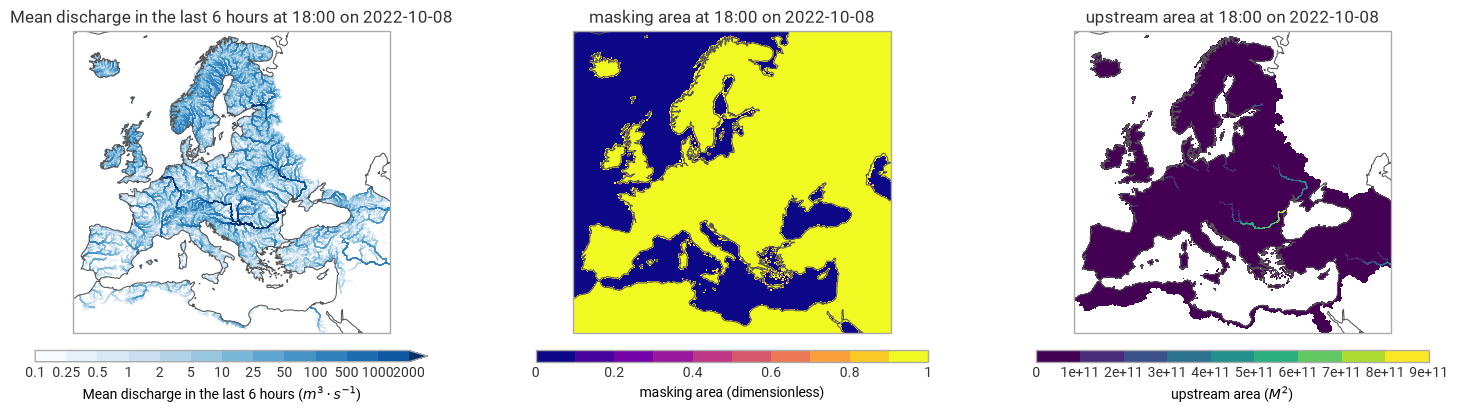

In [6]:
ekp.geo.plot(data)